<div style="background-color: white; border: 2px solid black; border-radius: 20px; padding: 15px 25px; display: inline-block; color: black;">
<font face='Liberation serif' size=3>
    
#### **Привет, Мария!** 👋

Меня зовут Артём Пиляй. Я буду проверять твой проект «*Исследование A/B-тестирования нового алгоритма рекомендаций в развлекательном приложении*» 📱.

---

В рамках корпоративной этики мы общаемся на «ты». Но если лучше на «Вы», то важно обозначить это сразу.

---

Комментарии к проекту размещены в отдельных ячейках Markdown. Для удобства они отображаются в меню **Contents** слева. 

Я использую четыре типа комментариев:

---

✅ Главый комментарий — значит, всё сделано хорошо. А ещё здесь могут быть подсказки, как улучшить проект.

---

⚠️ Рекомендуемый к исправлению — лучше внести правки, хотя это не критично для текущего проекта. Но начиная со следующего проекта такие комментарии будут считаться критическими.

---

⛔ Обязателен к исправлению — важный комментарий, который нужно доработать, чтобы проект прошёл проверку.

---

🚩 Красный флаг — проверку пришлось прервать, так как действие в ячейке выше повлияло на весь дальнейший проект.
    
<br>    

<div style="border: 2px solid black; border-radius: 20px; padding: 15px 25px; display: inline-block;">

Важно! Не перемещай и не удаляй мои комментарии. Если они будут удалены, я верну последнюю версию проекта, где они сохранились.

</div>

🏁 [Перейти к итогам ревью](#results)

<a id="start"></a>

# Разработка A/B-тестирования и анализ результатов

- Автор: Новикова Мария Федоровна
- Дата: 02.07.2025

Вы работаете продуктовым аналитиком в компании, которая разрабатывает развлекательное приложение с функцией «бесконечной» ленты, как, например, в приложениях с короткими видео. В вашем приложении существует две модели монетизации: первая — ежемесячная платная подписка, которая позволяет пользователям смотреть ленту без рекламы, вторая — демонстрация рекламы для пользователей, которые ещё не оформили подписку.

Команда разработчиков рекомендательных систем создала новый алгоритм рекомендаций, который, по их мнению, будет показывать более интересный контент для каждого пользователя. Вас, как аналитика, просят помочь рассчитать параметры A/B-теста, который позволит проверить эту гипотезу, и проанализировать его результаты.

### Цели и задачи проекта

<font color='#777778'> Цель проекта: 
- разработка А/В тестирования и анализ результатов.</font>

<font color='#777778'> Задачи проекта:
- ознакомление с данными;
- проверка корректности данных, в том числе приведение предобработки;
- проведение статистических тестов;
- составление итоговых выводов и результатов по итогам проведенного анализа. </font>

### Содержимое проекта


<font color='#777778'>Оглавление:
* [1. 1  Описание данных](#1)
    * [1.1 Промежуточный вывод](#1.1)
    * [1.2 Подготовка единого датафрейма](#1.2)
* [2.1  1. Работа с историческими данными (EDA)](#2.1)
    * [2.1.1  1.1. Загрузка исторических данных](#2.1.1)    
    * [2.1.2  1.2. Знакомство с данными](#2.1.2)
    * [2.1.3  1.3. Анализ числа регистраций](#2.1.3)
    * [2.1.4  1.4. Анализ числа просмотренных страниц](#2.1.4)
    * [2.1.5  1.5. Доля пользователей, просмотревших более четырёх страниц](#2.1.5)
* [2.2  2. Подготовка к тесту](#2.2)
    * [2.2.1  2.1 Формулировка нулевой и альтернативной гипотез](#2.2.1)
    * [2.2.2  2.2. Расчёт размера выборки](#2.2.2)
    * [2.2.3  2.3. Расчёт длительности A/B-теста](#2.2.3)
* [2.3  3. Мониторинг А/В-теста](#2.3)
    * [2.3.1  3.1. Проверка распределения пользователей](#2.3.1)
    * [2.3.2  3.2. Проверка пересечений пользователей](#2.3.2)
    * [2.3.3  3.3. Равномерность разделения пользователей по устройствам](#2.3.3)
    * [2.3.4  3.4. Равномерность распределения пользователей по регионам](#2.3.4)
    * [2.3.5  3.5. Вывод после проверки A/B-теста](#2.3.5)
* [2.4  4. Проверка результатов A/B-теста](#conclusions)(#2.4)
    * [2.4.1  4.1. Получение результатов теста и подсчёт основной метрики](#2.4.1)
    * [2.4.2  4.2. Проверка корректности результатов теста](#2.4.2)
    * [2.4.3  4.3. Сравнение доли успешных сессий](#2.4.3)
    * [2.4.4  4.4. Насколько статистически значимо изменение ключевой метрики](#2.4.4)
    * [2.4.5  4.5. Вывод по результатам A/B-эксперимента](#2.4.5)</font>
    
---

## Описание данных<a id='1'></a>

Вы будете работать с тремя таблицами:

- `sessions_project_history.csv` — таблица с историческими данными по сессиям пользователей на период с 2025-08-11 по 2025-09-23. Путь к файлу: `/datasets/sessions_project_history.csv`.

- `sessions_project_test_part.csv` — таблица с данными за первый день проведения A/B-теста, то есть за 2025-10-14. Путь к файлу: `/datasets/sessions_project_test_part.csv`.

- `sessions_project_test.csv` — таблица с данными за весь период проведения A/B-теста, то есть с 2025-10-14 по 2025-11-02. Путь к файлу: `/datasets/sessions_project_test.csv`.

У этих таблиц почти совпадает структура и содержание колонок, различаются лишь периоды наблюдения.

Поля таблиц `sessions_project_history.csv`, `sessions_project_test.csv`, `sessions_project_test_part.csv`:

- `user_id` — идентификатор пользователя;

- `session_id` — идентификатор сессии в приложении;

- `session_date` — дата сессии;

- `session_start_ts` — дата и время начала сессии;

- `install_date` — дата установки приложения;

- `session_number` — порядковый номер сессии для конкретного пользователя;

- `registration_flag` — является ли пользователь зарегистрированным;

- `page_counter` — количество просмотренных страниц во время сессии;

- `region` — регион пользователя;

- `device` — тип устройства пользователя;

- `test_group` — тестовая группа (в таблице с историческими данными этого столбца нет).


## Что нужно сделать
Ваши задачи: рассчитать параметры теста, оценить корректность его проведения и проанализировать результаты эксперимента.

<!-- ✅⚠️⛔❌🚩 -->
<div style="background-color: white; border: 2px solid black; border-radius: 20px; padding: 15px 25px; display: inline-block; color: black;">

##### ✅ Вводная часть

---
    
✅ Отличное начало.

    
---
    
💬 Здесь можно оставить комментарий

### 1. Работа с историческими данными (EDA) <a id='2.1'></a>

#### 1.1. Загрузка исторических данных<a id='2.1.1'></a>
На первом этапе поработайте с историческими данными приложения:

- Импортируйте библиотеку pandas.

- Считайте и сохраните в датафрейм `sessions_history` CSV-файл с историческими данными о сессиях пользователей `sessions_project_history.csv`.

Выведите на экран первые пять строк полученного датафрейма.

In [1]:
# Импортируем библиотеки
import pandas as pd
import numpy as np

# Загружаем библиотеки для визуализации данных
import matplotlib.pyplot as plt
import seaborn as sns 

from statsmodels.stats.power import NormalIndPower
from statsmodels.stats.proportion import proportion_effectsize
from math import ceil
from scipy.stats import ttest_ind
from math import floor
from statsmodels.stats.proportion import proportions_ztest

# Загрузим библиотеку для построения диаграммы Венна
try:
    from matplotlib_venn import venn2
except ImportError:
    !pip install matplotlib-venn -q
    from matplotlib_venn import venn2
    
    

<!-- ✅⚠️⛔❌🚩 -->
<div style="background-color: white; border: 2px solid black; border-radius: 20px; padding: 15px 25px; display: inline-block; color: black;">
    
##### ✅ Python Enhancement Proposal №8.
    
---    

⚠️ Я понимаю, что в прекоде импорты идут дальше, но согласно руководству PEP 8 лучше:
- ✅ отделять импорт от основного кода;
- ❌ импортировать все библиотеки в одной ячейке в начале проекта.  

Это делает код более структурированным и понятным.

Это помогает:
- Сразу видеть, какое окружение необходимо для запуска проекта.
- Избежать дублирования импортов в разных частях кода.
- Облегчить отладку и переносимость проекта.
    
Подробнее о PEP 8 можно прочитать в статье [*PEP 8 - руководство по написанию кода на Python*](https://pythonworld.ru/osnovy/pep-8-rukovodstvo-po-napisaniyu-koda-na-python.html).    
    
---
    
💬 Переместила все загрузки в начало проекта. До этого делала так, потому что по заданиям почему-то нужно было дальше загружать... Для построения диаграммы Венна оставила через try-except загрузки, мне показалось важным в проекте показать, что могу делать и так. Остальные не стала аналогично загружать, потому что кажется это перегрузит код... Насколько есть смысл в реальной работе делать через try-except загрузки?
    
---
    
✅ try-except нужен, когда ошибка может возникнуть, но программа должна продолжить работу, а не упасть.

Примеры: загрузка файла, запрос в интернет, ввод данных, подключение к базе. Плюс все ошибки можно логировать.
    
Так что да, смысл точно есть.    

In [2]:
# добавим фукнцию для подписи значений на график
def autolabel(rects, labels=None, height_factor=1.01):
    for i, rect in enumerate(rects):
        height = rect.get_height()
        if labels is not None:
            try:
                label = labels[i]
            except (TypeError, KeyError):
                label = ' '
        else:
            label = '%.2f' % height
        ax.text(rect.get_x() + rect.get_width()/2., height_factor*height,
                '{}'.format(label),
                ha='center', va='bottom')

In [3]:
# Установим опцию, чтобы выводить на экран все столбцы датафрейм для упрощения анализа.
pd.set_option('display.max_columns', None)

In [4]:
# Выгружаем данные в переменные 
sessions_history_df = pd.read_csv('https://code.s3.yandex.net/datasets/sessions_project_history.csv')

In [5]:
# Выводим 5 первых строк
sessions_history_df.head()

,user_id,session_id,session_date,session_start_ts,install_date,session_number,registration_flag,page_counter,region,device
0,E302123B7000BFE4,F9AF61A0C2023832,2025-08-15,2025-08-15 17:47:35,2025-08-15,1,0,3,CIS,iPhone
1,2530F72E221829FB,85003A206CBDAC6F,2025-08-15,2025-08-15 16:42:14,2025-08-15,1,0,4,MENA,Android
2,876E020A4FC512F5,3677423E49D72DEE,2025-08-15,2025-08-15 12:30:00,2025-08-15,1,0,4,EU,PC
3,2640B349E1D81584,956B45F5915CA225,2025-08-15,2025-08-15 15:31:31,2025-08-15,1,0,4,CIS,Android
4,94E1CBFAEF1F5EE9,83BF0DA35F9F1F40,2025-08-15,2025-08-15 21:33:53,2025-08-15,1,0,3,CIS,Android


In [6]:
# Выводим информацию о датафрейме
sessions_history_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 435924 entries, 0 to 435923
Data columns (total 10 columns):
 #   Column             Non-Null Count   Dtype 
---  ------             --------------   ----- 
 0   user_id            435924 non-null  object
 1   session_id         435924 non-null  object
 2   session_date       435924 non-null  object
 3   session_start_ts   435924 non-null  object
 4   install_date       435924 non-null  object
 5   session_number     435924 non-null  int64 
 6   registration_flag  435924 non-null  int64 
 7   page_counter       435924 non-null  int64 
 8   region             435924 non-null  object
 9   device             435924 non-null  object
dtypes: int64(3), object(7)
memory usage: 33.3+ MB


In [7]:
# Меняем тип данных на datetime64 в датафрейме
for column in ['session_date', 'session_start_ts', 'install_date']:
    sessions_history_df[column] = pd.to_datetime(sessions_history_df[column])

In [8]:
# Проверим данные в столбцах, какие уникальные значения имеются в столбце
nuniq_sessions_history_df = pd.DataFrame({'Кол-во уникальных значений': sessions_history_df.nunique()})
nuniq_sessions_history_df

,Кол-во уникальных значений
user_id,134039
session_id,435924
session_date,44
session_start_ts,373059
install_date,31
session_number,10
registration_flag,2
page_counter,7
region,3
device,4


In [9]:
# Проверим данные в столбцах, какие уникальные значения имеются в столбце
columns = ['session_number', 'registration_flag', 'page_counter', 'region', 'device']
for column in columns:
    uniq = sessions_history_df[column].unique()
    print(f'В столбце {column} имеются уникальные значения {uniq}')

В столбце session_number имеются уникальные значения [ 1  2  3  4  5  6  7  8  9 10]
В столбце registration_flag имеются уникальные значения [0 1]
В столбце page_counter имеются уникальные значения [3 4 5 1 2 6 7]
В столбце region имеются уникальные значения ['CIS' 'MENA' 'EU']
В столбце device имеются уникальные значения ['iPhone' 'Android' 'PC' 'Mac']


In [10]:
# Проверим данные в столбцах, какие временные интервалы указаны в столбцах
columns = ['session_date', 'session_start_ts', 'install_date']
for column in columns:
    min_column = sessions_history_df[column].min()
    max_column = sessions_history_df[column].max()
    print(f'В столбце {column} рассматривается период от {min_column} до {max_column}')

В столбце session_date рассматривается период от 2025-08-11 00:00:00 до 2025-09-23 00:00:00
В столбце session_start_ts рассматривается период от 2025-08-11 00:00:25 до 2025-09-23 23:51:46
В столбце install_date рассматривается период от 2025-08-11 00:00:00 до 2025-09-10 00:00:00


**Итог по разделу:**
- Были загружены минимально необходимые библиотеки для работы 
- Загружены исторические данные по сессиям пользователей
- Изменены типы данных на тип datetime в столбцах 'session_date', 'session_start_ts', 'install_date'. В прочих столбцах данные соответствуют верному типу данных.
- Проведена проверка уникальных значений в столбцах 'session_number', 'registration_flag', 'page_counter', 'region', 'device', данные соответствуют фактическим данным. Исторические данные соответствуют периоду до 23.08.2025 г. (с датой регистрации пользователей до 10.09.2023 г. Исторические данные по сессиям пользователей представлены за период в 44 дня, по датам регистрации пользователей за 1 месяц (31 календарный день).
- Наименования столбцов соответствуют стилю snake_case.

<!-- ✅⚠️⛔❌🚩 -->
<div style="background-color: white; border: 2px solid black; border-radius: 20px; padding: 15px 25px; display: inline-block; color: black;">

##### ✅ Аналитическая часть работы

---    
    
✅ Молодец, что делаешь выводы о проделанной работе в ходе знакомства с данными.
    
---

💬 спасибо 👍   

#### 1.2. Знакомство с данными<a id='2.1.2'></a>
- Для каждого уникального пользователя `user_id` рассчитайте количество уникальных сессий `session_id`.

- Выведите на экран все данные из таблицы `sessions_history` для одного пользователя с наибольшим количеством сессий. Если таких пользователей несколько, выберите любого из них.

- Изучите таблицу для одного пользователя, чтобы лучше понять логику формирования каждого столбца данных.



In [11]:
# Рассчитаем и выведем количество уникальных сессий для каждого уникального пользователя
session_users = (sessions_history_df.groupby('user_id').agg({'session_id': 'nunique'})).reset_index()
session_users

,user_id,session_id
0,00005FB6A13A6FBE,2
1,0000B15A18D77ED9,3
2,0000C4E3A4A571A9,2
3,000293FAF9E67A81,4
4,00029C5AE889A6C3,2
...,...,...
134034,FFFCDE7746148710,4
134035,FFFDD413285E753F,3
134036,FFFECBA0F2578AB0,2
134037,FFFEDB68228B5F21,5


In [12]:
# Найдем одного пользователя с наибольшим количеством сессий
user_max =sessions_history_df[['user_id', 'session_number']].loc[sessions_history_df['session_number'].idxmax()]
user_max 

user_id           10E0DEFC1ABDBBE0
session_number                  10
Name: 414743, dtype: object

In [13]:
# Выведем данные пользователя с наибольшим количеством сессий
data_users_max = sessions_history_df.loc[sessions_history_df['user_id'] == user_max['user_id']]
data_users_max

,user_id,session_id,session_date,session_start_ts,install_date,session_number,registration_flag,page_counter,region,device
115558,10E0DEFC1ABDBBE0,B8F0423BBFFCF5DC,2025-08-14,2025-08-14 13:57:39,2025-08-14,1,0,4,CIS,Android
191751,10E0DEFC1ABDBBE0,87CA2FA549473837,2025-08-15,2025-08-15 16:42:10,2025-08-14,2,0,3,CIS,Android
239370,10E0DEFC1ABDBBE0,4ADD8011DCDCE318,2025-08-16,2025-08-16 19:53:21,2025-08-14,3,0,3,CIS,Android
274629,10E0DEFC1ABDBBE0,DF0FD0E09BF1F3D7,2025-08-17,2025-08-17 15:03:43,2025-08-14,4,0,1,CIS,Android
302501,10E0DEFC1ABDBBE0,3C221774B4DE6885,2025-08-18,2025-08-18 17:29:14,2025-08-14,5,0,4,CIS,Android
325557,10E0DEFC1ABDBBE0,031BD7A67048105B,2025-08-19,2025-08-19 13:23:55,2025-08-14,6,0,2,CIS,Android
345336,10E0DEFC1ABDBBE0,FF4315CF4AD4B100,2025-08-20,2025-08-20 19:31:54,2025-08-14,7,0,2,CIS,Android
377532,10E0DEFC1ABDBBE0,4045FEA0747203B4,2025-08-22,2025-08-22 17:54:13,2025-08-14,8,0,2,CIS,Android
403538,10E0DEFC1ABDBBE0,344B086C421C7F37,2025-08-24,2025-08-24 14:46:13,2025-08-14,9,0,2,CIS,Android
414743,10E0DEFC1ABDBBE0,054F20BA371E4C9D,2025-08-25,2025-08-25 18:36:41,2025-08-14,10,0,3,CIS,Android


<!-- ✅⚠️⛔❌🚩 -->
<div style="background-color: white; border: 2px solid black; border-radius: 20px; padding: 15px 25px; display: inline-block; color: black;">

##### ✅ Знакомство с данными

---    
    
✅ Молодец, использование `idmax` помогает упростить и ускорить анализ данных.

Преимущества метода:
- Оптимизация кода — сокращает количество вычислений по сравнению с альтернативными методами.
- Быстродействие — позволяет находить нужное значение без дополнительной сортировки.
- Читаемость — код становится лаконичным и понятным.
- Эффективность — снижает нагрузку при обработке больших объемов данных.

Подробнее можно ознакомиться в документации по Pandas: [Pandas idxmax()](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.idxmax.html)

---

💬 спасибо 👍

**Итог по разделу:**
- Пользователь 10E0DEFC1ABDBBE0 имеет наибольшее количество сессий. Пользователь не зарегистрирован, просматривает до 4 страниц.
- В течение одного дня пользования приложения только один уникальный id сессии.

#### 1.3. Анализ числа регистраций<a id='2.1.3'></a>
Одна из важнейших метрик продукта — число зарегистрированных пользователей. Используя исторические данные, визуализируйте, как менялось число регистраций в приложении за время его существования.

- Агрегируйте исторические данные и рассчитайте число уникальных пользователей и число зарегистрированных пользователей для каждого дня наблюдения. Для простоты считайте, что у пользователя в течение дня бывает одна сессия максимум и статус регистрации в течение одного дня не может измениться.

- Постройте линейные графики общего числа пользователей и общего числа зарегистрированных пользователей по дням. Отобразите их на одном графике.

- Постройте отдельный линейный график доли зарегистрированных пользователей от всех пользователей по дням.

- На обоих графиках должны быть заголовок, подписанные оси X и Y, сетка и легенда.

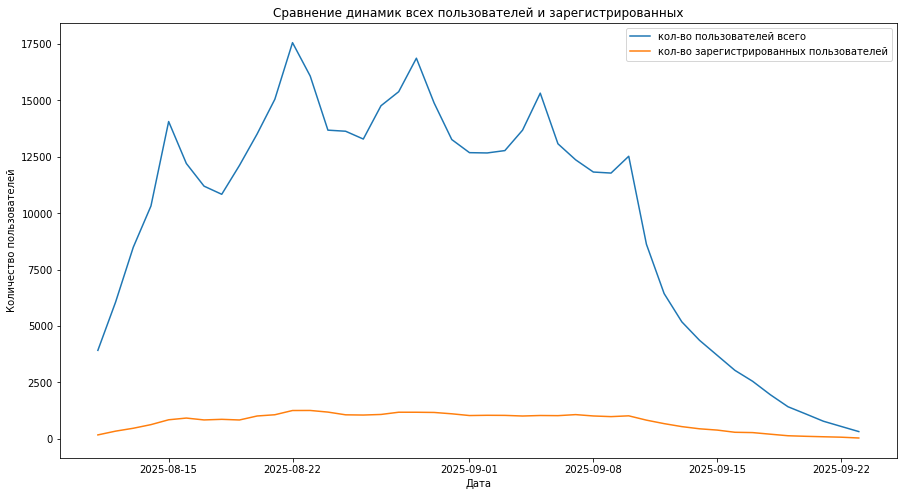

In [14]:
# Агрегируем данные для каждого дня о числе уникальных пользователей и числе зарегистрированых пользователей
date_session = (sessions_history_df.groupby('session_date').agg({'user_id': 'nunique', 'registration_flag': 'sum'})).reset_index()

# Построем линейных график по собранным данным
x = date_session.session_date
y_a = date_session.user_id
y_b = date_session.registration_flag

plt.figure(figsize=(15, 8))
plt.plot(x, y_a, label ='кол-во пользователей всего')
plt.plot(x, y_b, label ='кол-во зарегистрированных пользователей')

plt.xlabel("Дата")
plt.ylabel("Количество пользователей")
plt.legend()
plt.title('Сравнение динамик всех пользователей и зарегистрированных')
plt.show()

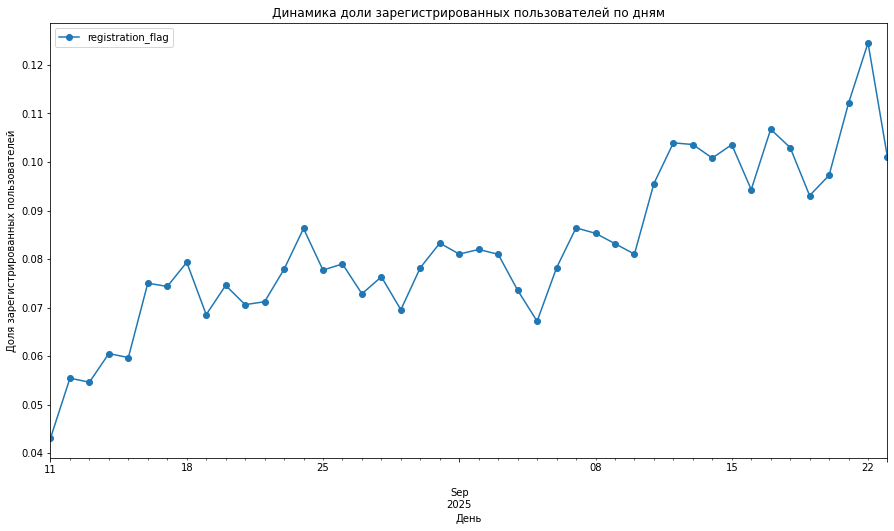

In [15]:
# Строим линейный график динамики доли зарегистрированных пользователей
sessions_history_df.groupby('session_date')['registration_flag'].mean().plot(
    kind='line',
    marker='o',
    title = 'Динамика доли зарегистрированных пользователей по дням',
    legend = True,
    figsize=(15, 8)
)

# Подписываем и отображаем график
plt.xlabel('День')
plt.ylabel('Доля зарегистрированных пользователей')
plt.show()

**Итог по разделу:**
- Динамика общего количества пользователей и количества зарегистрированы пользователей схожая, вершины находится в конце первой неделю исследуемого периода. Наблюдаются систематические скачки роста количества пользователей в выходные дни, имеется тенденция к снижению количества пользователей в конце рассматриваемого периода. 

<!-- ✅⚠️⛔❌🚩 -->
<div style="background-color: white; border: 2px solid black; border-radius: 20px; padding: 15px 25px; display: inline-block; color: black;">

##### ✅ Анализ числа регистраций

---

✅ Почти все отлично.

---    
    
⛔ Осталось добавить еще один график.

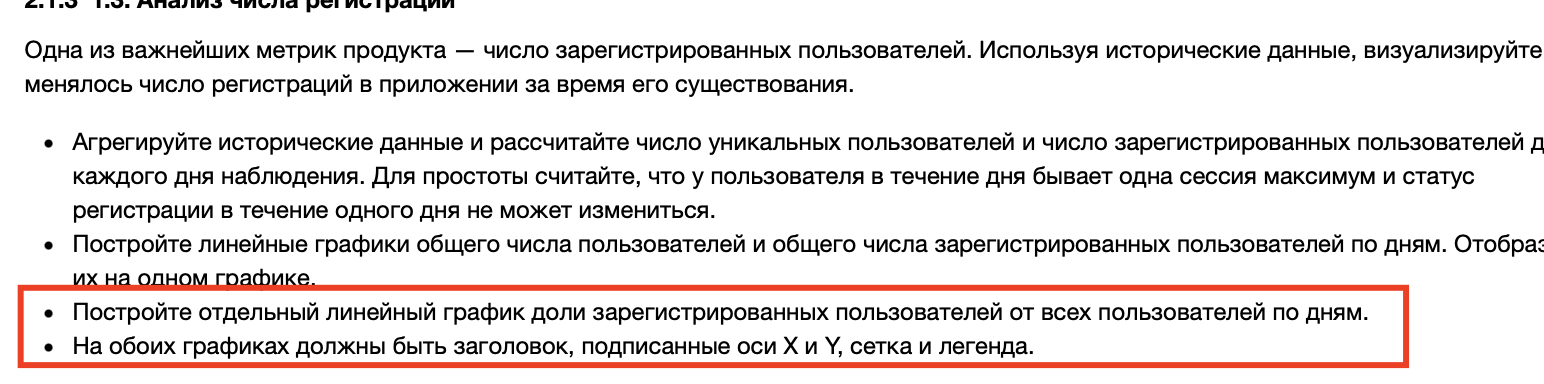    

---

💬 Очень жаль, что я упустила часть задания... Добавила! По заданию необходимо добавить легенду во все графики, но на мой взгляд в последнем графике динамике доли легенда не нужна. Оставила, чтобы соответствовало заданию.
    
---
    
✅ Согласен с тобой, легенда там не нужна.    

#### 1.4. Анализ числа просмотренных страниц<a id='2.1.4'></a>
Другая важная метрика продукта — число просмотренных страниц в приложении. Чем больше страниц просмотрено, тем сильнее пользователь увлечён контентом, а значит, выше шансы, что он зарегистрируется и оплатит подписку.

- Найдите количество сессий для каждого значения количества просмотренных страниц. Например: одну страницу просмотрели в 29 160 сессиях, две страницы — в 105 536 сессиях и так далее.

- Постройте столбчатую диаграмму, где по оси X будет число просмотренных страниц, по оси Y — количество сессий.

- На диаграмме должны быть заголовок, подписанные оси X и Y.

In [16]:
# Для каждого количества просмотренных страниц найдем количество уникальных сессий
page_gr = sessions_history_df.groupby('page_counter')['session_id'].nunique()
page_gr

page_counter
1     29160
2    105536
3    166690
4    105569
5     26288
6      2589
7        92
Name: session_id, dtype: int64

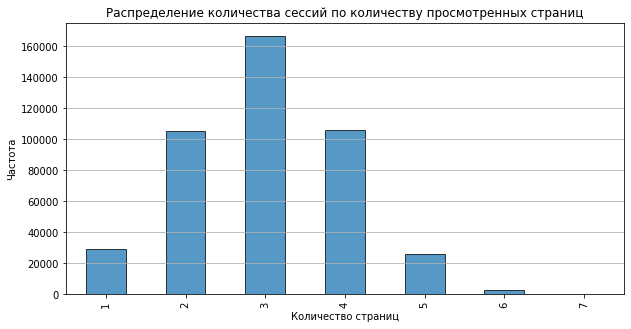

In [17]:
# Построим столбцатую лиаграмму по собранным данным 
plt.figure(figsize=(10, 5))

# Строим диаграмму
page_gr.plot(kind='bar', # Тип графика - столбчатая диаграмма
            alpha=0.75,
            edgecolor='black',
            legend=False)

# Настраиваем оформление графика
plt.title('Распределение количества сессий по количеству просмотренных страниц')
plt.xlabel('Количество страниц')
plt.ylabel('Частота')
# Добавляем сетку графика
plt.grid(axis='y')

# Выводим график
plt.show() 


**Итог по разделу:**
- Распределение количества сессий по количеству просмотренных страниц нормальное , пик распределения смещен в левую сторону и находится в значении трех просматриваемых страниц. Имеются единичные выбросы в правом хвосте: просмотр семи страниц составляет 92 ед.

<!-- ✅⚠️⛔❌🚩 -->
<div style="background-color: white; border: 2px solid black; border-radius: 20px; padding: 15px 25px; display: inline-block; color: black;">

##### ✅ Анализ числа просмотренных страниц

---    
    
✅ Отлично, выбран правильный тип графика, а также добавлены название и подписи осей.

Преимущества такого подхода:
- Наглядность — столбчатая диаграмма хорошо подходит для сравнения дискретных данных.
- Читаемость — благодаря названию и подписям осей график легко интерпретировать.

Подробнее о выборе графиков можно прочитать в статье: [Matplotlib – Визуализация данных](https://matplotlib.org/stable/plot_types/index.html).


---

💬 спасибо 👍

#### 1.5. Доля пользователей, просмотревших более четырёх страниц<a id='2.1.5'></a>
Продуктовая команда продукта считает, что сессии, в рамках которых пользователь просмотрел 4 и более страниц, говорят об удовлетворённости контентом и алгоритмами рекомендаций. Этот показатель является важной прокси-метрикой для продукта.

- В датафрейме `sessions_history` создайте дополнительный столбец `good_session`. В него войдёт значение `1`, если за одну сессию было просмотрено 4 и более страниц, и значение `0`, если было просмотрено меньше.

- Постройте график со средним значением доли успешных сессий от всех сессий по дням за весь период наблюдения.

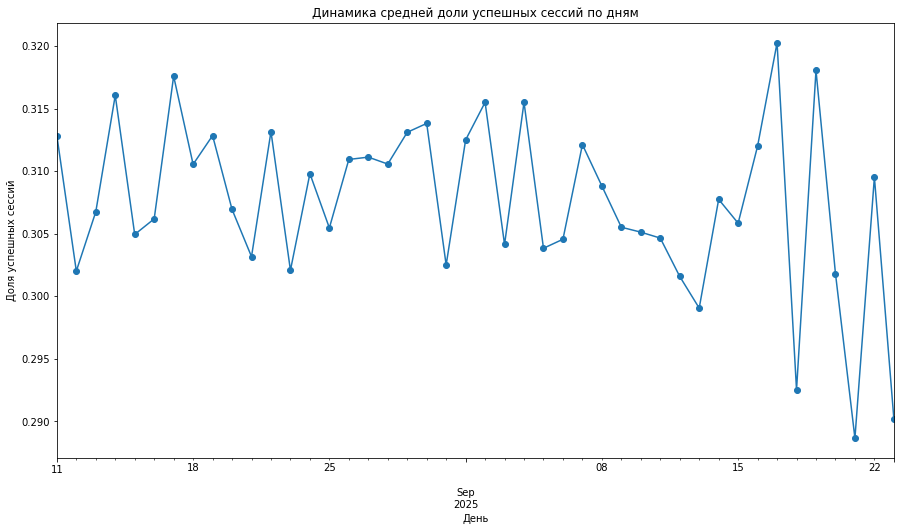

In [18]:
sessions_history_df['good_session'] = 0
sessions_history_df.loc[sessions_history_df['page_counter'] >= 4, 'good_session'] = 1

# Строим линейный график
sessions_history_df.groupby('session_date')['good_session'].mean().plot(
    kind='line',
    marker='o',
    title = 'Динамика средней доли успешных сессий по дням',
    legend = False,
    figsize=(15, 8)
)

# Подписываем и отображаем график
plt.xlabel('День')
plt.ylabel('Доля успешных сессий')
plt.show()

**Итог по разделу:**
- Выборочное среднее по количеству просматриваемых страниц находится в значении 3. Это значит, что большинство пользователей просматривает 3 страницы. В связи с этим, продуктовой команде стоит рассматривать повышение удовлетворенности и заинтересованности пользователей через повышение этого показателя. Для анализа этого показателя был создан дополнительный столбец 'good_session'.
- Согласно динамике доли успешных сессий возможно заметить, что такая доля имеет скаччки, в среднем находится в пределах 0,3-0,315. Также стоит отметить, что доля падает в конце рассматриваемого периода. 


<div style="background-color: white; border: 2px solid black; border-radius: 20px; padding: 15px 25px; display: inline-block; color: black;">

##### ✅  Доля пользователей, просмотревших более четырёх страниц

---

✅ Правильно выделена доля успешных сессий.

- Можно также учитывать возможную цикличность активности пользователей, чтобы точнее планировать тесты.
- Так же можно отметить, что под конец периода был спад в активности пользователей.



---

💬 спасибо 👍
    Да, я там в итогах отмечала про скачки и про спад в конце периода

### 2. Подготовка к тесту<a id='2.2'></a>
При планировании теста необходимо проделать несколько важных шагов:

- Сформулировать нулевую и альтернативную гипотезы

- Определиться с целевой метрикой.

- Рассчитать необходимый размер выборки.

- Исходя из текущих значений трафика рассчитать необходимую длительность проведения теста.

#### 2.1 Формулировка нулевой и альтернативной гипотез<a id='2.2.1'></a>

Перед тем как проводить А/B-тест, необходимо сформулировать нулевую и альтернативную гипотезы. Напомним изначальное условие: команда разработчиков рекомендательных систем создала новый алгоритм, который, по их мнению, будет показывать более интересный контент для каждого пользователя.

О какой метрике идёт речь? Как она будет учтена в формулировке гипотез?

Сформулируйте нулевую и альтернативную гипотезы:

**Ключевая метрика:** Среднее количество просматриваемых сессий на пользователя в день

**Нулевая гипотеза:**
Среднее количество просматриваемых сессий на пользователя в день равны в группах А и В.
μ(А) = μ(В)

**Альтернативная гипотеза (одностороняя):**
В группе В среднее количество просматриваемых сессий на пользователя в день выше, чем в группе А.
μ(B) > μ(A)


<!-- ✅⚠️⛔❌🚩 -->
<div style="background-color: white; border: 2px solid black; border-radius: 20px; padding: 15px 25px; display: inline-block; color: black;">

##### ✅ Формулировка гипотез перед статистическим тестом

---

✅ Молодец, что перед проверкой теста  формулируешь нулевую (H₀) и альтернативную (H₁) гипотезы. Так понятно, какие различия мы проверяем.


Подробнее можно почитать [здесь](https://allatambov.github.io/psms/pdf/hypo-test.pdf)    

---

⚠️ "Только выше, чем в группе А", корректнее записать μ(B) > μ(A)

Тестовая группа всегда должна быть первой.

---

💬 Сейчас пересмотрела теорию, удивительно, но у нас везде именно такая запись ведется, именно сначала группа А, потом В, поэтому и выбрана была такая запись. Спасибо, учту.
    
---
    
✅ Да, я знаю. Но все же лучше записывать как я наисал выше.    

#### 2.2. Расчёт размера выборки<a id='2.2.2'></a>
В рамках курса вы уже рассчитывали размеры выборки и  использовали для этого онлайн-калькулятор. В этом задании предлагаем воспользоваться готовым кодом и рассчитать необходимое для вашего эксперимента количество пользователей.

Для этого установите в коде ниже следующие параметры:

- Уровень значимости — 0.05.

- Вероятность ошибки второго рода — 0.2.

- Мощность теста.

- Минимальный детектируемый эффект, или MDE, — 3%. Обратите внимание, что здесь нужно указать десятичную дробь, а не процент.

При расчёте размера выборки используйте метод `solve_power()` из класса `power.NormalIndPower` модуля `statsmodels.stats`.

Запустите ячейку и изучите полученное значение.

In [19]:
# Задаём параметры
alpha = 0.05  # Уровень значимости
beta = 0.2  # Ошибка второго рода, часто 1 - мощность
power = 1 - beta  # Мощность теста
p = 0.3 # Базовый уровень доли
mde = 0.03 * p  # Минимальный детектируемый эффект
effect_size = proportion_effectsize(p, p + mde)

# Инициализируем класс NormalIndPower
power_analysis = NormalIndPower()

# Рассчитываем размер выборки
sample_size = power_analysis.solve_power(
    effect_size = effect_size,
    power = power,
    alpha = alpha,
    ratio = 1 # Равномерное распределение выборок
)

print(f"Необходимый размер выборки для каждой группы: {int(sample_size)}")

Необходимый размер выборки для каждой группы: 41040


<div style="background-color: white; border: 2px solid black; border-radius: 20px; padding: 15px 25px; display: inline-block; color: black;">

##### ✅ Связь ошибки II рода и мощности критерия

---    

✅ Здорово, что связана ошибка второго рода и мощность критерия через `power = 1 - beta`. Это важный аспект статистического анализа, который помогает оценить вероятность обнаружения реального эффекта.  

Преимущества такого подхода:
- Позволяет осознанно выбирать размер выборки для теста.  
- Помогает сбалансировать риск ложных отрицательных результатов.  
- Улучшает интерпретацию результатов A/B-тестирования.  

Кстати, есть еще очень интересный бесплатный курс от Практикума по A/B-тестированию — там можно более детально познакомиться с расчетом длительности теста:  
[Practicum – Основы статистики](https://practicum.yandex.ru/profile/statistics-basic/)  

---

💬 спасибо 👍

---

**Итог по разделу:**
- В результате проведенного расчета было получено, что необходимый размер для каждой выборки 41 040 пользователей.
- Для расчета были заданы параметры:
        - уровень значимости 0,05 (5% вероятности ошибки первого уровня)
        - мощность теста 0,20
        - базовый уровень доли 0,3. Согласно разделу 2.1.5 динамики доли за исторический период установлено, что большую часть периода находится на уровне 0,305-0,315, на конец периода снизилась менее чем до 0,29. Следовательно, за базовый уровень принята доля до уровня снижения, цель разработки новой рекомендательной системы будет к возврату к началу "исторического" периода.
        - MDE принят в размере 3%, т.е. минимально желаемый эффект от теста будет рост доли успешных сессий до 0,309.

#### 2.3. Расчёт длительности A/B-теста<a id='2.2.3'></a>

Используйте данные о количестве пользователей в каждой выборке и среднем количестве пользователей приложения. Рассчитайте длительность теста, разделив одно на другое.

- Рассчитайте среднее количество уникальных пользователей приложения в день.

- Определите длительность теста исходя из рассчитанного значения размера выборок и среднего дневного трафика приложения. Количество дней округлите в большую сторону.

In [20]:
# Среднее количество пользователей приложения в день по историческим данным
avg_daily_users = sessions_history_df.groupby('session_date')['user_id'].nunique().mean().round(2)

# Рассчитываем длительность теста в днях как отношение размера выборки к среднему числу пользователей
test_duration = ceil(sample_size*2/avg_daily_users)

print(f"Рассчитанная длительность A/B-теста при текущем уровене трафика в {avg_daily_users} пользователей в день составит {test_duration} дней")

Рассчитанная длительность A/B-теста при текущем уровене трафика в 9907.36 пользователей в день составит 9 дней


<!-- ✅⚠️⛔❌🚩 -->
<div style="background-color: white; border: 2px solid black; border-radius: 20px; padding: 15px 25px; display: inline-block; color: black;">

##### ✅  Расчёт длительности A/B-теста

---

⛔️ В расчёте длительности теста не учтено, что A/B-тест состоит из двух групп (A и B).

Размер выборки используется только для одной группы, но необходимо учитывать обе, поэтому итоговое значение тестовой длительности будет заниженным.

Нужно умножить `sample_size` на 2 перед делением на `avg_daily_users`.

---

💬 Да, не учла, поняла, исправила, итог откорректировала
    
---
    
✅ Все правильно, но важно понимать, что это допустимый минимальный срок, однако для повышения надёжности результатов теста желательно провести его дольше — например, на 14 дней, чтобы сгладить возможные колебания в поведении пользователей по дням недели и собрать больше данных для анализа.    
    
В нашем случае тест длится - 20 дней, за счёт чего общее число участников увеличивается. Поэтому мощность теста остаётся высокой — 99.97%. Это значит, что вероятность не заметить реальный эффект крайне мала.    

**Итог по разделу:**
- При расчетном значении каждой выборки 41040 пользователей, длительность теста составит 9 дней.

### 3. Мониторинг А/В-теста<a id='2.3'></a>

#### 3.1. Проверка распределения пользователей<a id='2.3.1'></a>

A/B-тест успешно запущен, и уже доступны данные за первые три дня. На этом этапе нужно убедиться, что всё идёт хорошо: пользователи разделены правильным образом, а интересующие вас метрики корректно считаются.

- Считайте и сохраните в датафрейм `sessions_test_part` CSV-файл с историческими данными о сессиях пользователей `sessions_project_test_part.csv`.

- Рассчитайте количество уникальных пользователей в каждой из экспериментальных групп для одного дня наблюдения.

- Рассчитайте и выведите на экран процентную разницу в количестве пользователей в группах A и B. Постройте любую удобную визуализацию, на которой будет видно возможное различие двух групп.

Для расчёта процентной разницы воспользуйтесь формулой:
$$P = 100 \cdot  \frac{|A − B|}{A}$$

In [21]:
# Выгружаем данные в переменные 
sessions_test_part_df = pd.read_csv('https://code.s3.yandex.net/datasets/sessions_project_test_part.csv')

In [22]:
# Выгружаем первые 5 строк датафрейма
sessions_test_part_df.head()

,user_id,session_id,session_date,session_start_ts,install_date,session_number,registration_flag,page_counter,region,device,test_group
0,3404844B53442747,B4901323BD537E45,2025-10-14,2025-10-14 19:28:49,2025-10-14,1,0,3,CIS,Android,B
1,3A2BF4D364E62D89,216FC619308F8788,2025-10-14,2025-10-14 21:11:04,2025-10-14,1,0,3,MENA,iPhone,A
2,79CDAE11E32B1597,EDFCE4AC1A504074,2025-10-14,2025-10-14 21:44:03,2025-10-14,1,0,3,CIS,iPhone,A
3,D6AF8D78297A931F,CF0AC0EEDE92C690,2025-10-14,2025-10-14 19:07:55,2025-10-14,1,0,4,CIS,PC,A
4,37E0CE723AE568E0,2E6ED45E8C86C4E9,2025-10-14,2025-10-14 15:39:44,2025-10-14,1,0,3,CIS,Mac,B


In [23]:
# Проверим период за который имеются первые данные теста
sessions_test_part_df['session_date'].unique()

array(['2025-10-14'], dtype=object)

In [24]:
# Рассчитаем количество пользователей в каждой группе
count_users_gr = sessions_test_part_df.groupby('test_group')['user_id'].nunique()
count_users_gr

test_group
A    1477
B    1466
Name: user_id, dtype: int64

In [25]:
# Рассчитаем долю пользователей в каждой группе
share = count_users_gr / count_users_gr.sum()
share

test_group
A    0.501869
B    0.498131
Name: user_id, dtype: float64

In [26]:
# Рассчитаем процентную разницу количества пользователей в группах
share_dif = 100 * abs(share['A'] - share['B']) / share['A']
print(f'Процентная разница в количестве пользователей в группах A и B составляет: {share_dif.round(2)}%, т.е. менее {ceil(share_dif)}%.')

Процентная разница в количестве пользователей в группах A и B составляет: 0.74%, т.е. менее 1%.


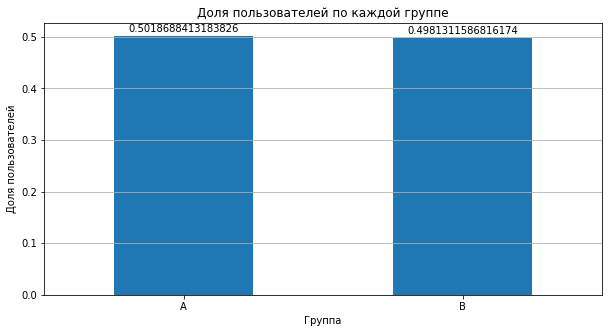

In [27]:
# Построим график столбчатой диаграммы
share.plot(kind='bar',
               title='Доля пользователей по каждой группе',
               legend=False,
               ylabel='Доля пользователей',
               xlabel='Группа',
               rot=0,
               figsize=(10,5))
plt.grid(axis='y')

ax = plt.gca()
autolabel(ax.patches, share, height_factor=1.01)

# Выводим график
plt.show()

**Итог по разделу:**
- За первый день проведения эксперимента в каждой группе участвовало свыше 1450 пользователей.
- Доля пользователей по каждой группе составляет около 50%, процентная разница составляет менее 1%. Таким образом, можно говорить о равномерном распределении пользователей в каждой группе.

<div style="background-color: white; border: 2px solid black; border-radius: 20px; padding: 15px 25px; display: inline-block; color: black;">


##### ✅ Проверка распределения пользователей

---

✅ Эта проверка важна по нескольким причинам:
    
    
- Правильность разделения пользователей: Чтобы результат A/B-теста был корректным, важно убедиться, что группы A и B были случайным образом разделены, а не случайным образом или по какому-либо смещённому принципу. Если группы не были равномерно разделены, это может привести к ошибочным выводам, так как различия в поведении пользователей могут быть вызваны не тестируемым фактором, а изначальной неоднородностью групп.
- Корректность расчёта метрик: Мы проверяем, что метрики, такие как количество уникальных пользователей, корректно считаются для каждой из групп. Это важно, потому что любые ошибки в учёте пользователей могут исказить результаты теста и привести к неверным выводам о влиянии изменений на поведение пользователей.
- Обнаружение аномалий: Если процентная разница в количестве пользователей между группами слишком велика, это может свидетельствовать о проблемах с разделением пользователей, таких как технические ошибки или неправильное распределение. Проверка позволяет выявить такие аномалии на ранних стадиях теста и скорректировать процесс.
- Убедительность результатов: Важно, чтобы тест был честным и справедливым. Если группа A имеет значительное преимущество по численности, то результаты могут быть искажены. Это проверка помогает удостовериться, что эксперимент был проведён корректно, и что его результаты можно использовать для объективных выводов.

---

💬 спасибо 👍

#### 3.2. Проверка пересечений пользователей<a id='2.3.2'></a>
Помимо проверки равенства количества пользователей в группах, полезно убедиться в том, что группы независимы. Для этого нужно убедиться, что никто из пользователей случайно не попал в обе группы одновременно.

- Рассчитайте количество пользователей, которые встречаются одновременно в группах A и B, или убедитесь, что таких нет.

In [28]:
# Выведем id пользователей, которые пересекаются в обеих группах
intersection = sessions_test_part_df.groupby('user_id').agg({'test_group': 'nunique'}).query('test_group > 1')
intersection

,test_group
user_id,


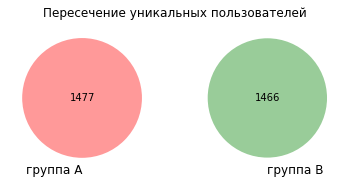

In [29]:
# Определим уникальные значения
A_id = set(sessions_test_part_df['user_id'].loc[sessions_test_part_df['test_group'] == 'A'].dropna().unique())
B_id = set(sessions_test_part_df['user_id'].loc[sessions_test_part_df['test_group'] == 'B'].dropna().unique())

# Строим диаграмму Венна
venn2([A_id, B_id], set_labels=('группа A', 'группа B'))
# Отображаем график
plt.title("Пересечение уникальных пользователей")
plt.show()

**Итог по разделу:**
- В результате проведенной проверки, в первый день эксперимента уникальные пользователи не пересекались, что также подтверждает корректность проведения эксперимента.

<div style="background-color: white; border: 2px solid black; border-radius: 20px; padding: 15px 25px; display: inline-block; color: black;">

##### ✅ Проверка пересечений пользователей между группами

---

✅ Альтернативный способ — использовать группировку, что может быть полезно при работе с большими данными:

```py
sessions_test_part.groupby('user_id').agg({'test_group': 'nunique'}).query('test_group > 1')
```

Этот метод позволяет сразу отфильтровать пользователей, которые встречаются в обеих группах.

---

💬 Добавила альтернативный вариант
    
---
    
✅ Супер.    

#### 3.3. Равномерность разделения пользователей по устройствам<a id='2.3.3'></a>
Полезно также убедиться в том, что пользователи равномерно распределены по всем доступным категориальным переменным — типам устройств и регионам.

Постройте две диаграммы:

- доля каждого типа устройства для пользователей из группы A,

- доля каждого типа устройства для пользователей из группы B.

Постарайтесь добавить на диаграммы все необходимые подписи, пояснения и заголовки, которые позволят сделать вывод о том, совпадает ли распределение устройств в группах A и B.


In [30]:
# рассчитаем уникальных пользователей по устройствам
total_device_a = sessions_test_part_df[sessions_test_part_df['test_group'] == 'A'].groupby('device')['user_id'].nunique()
share_device_a = round(total_device_a / total_device_a.sum() , 2)
share_device_a

device
Android    0.44
Mac        0.11
PC         0.25
iPhone     0.20
Name: user_id, dtype: float64

In [31]:
# рассчитаем уникальных пользователей по устройствам
total_device_b = sessions_test_part_df[sessions_test_part_df['test_group'] == 'B'].groupby('device')['user_id'].nunique()
share_device_b = round(total_device_b / total_device_b.sum() , 2)
share_device_b

device
Android    0.46
Mac        0.10
PC         0.26
iPhone     0.18
Name: user_id, dtype: float64

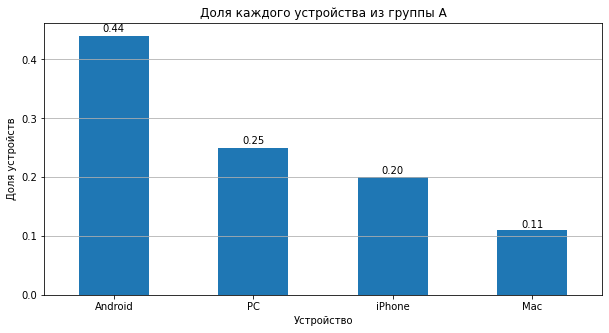

In [32]:
# Построим график столбчатой диаграммы
share_device_a.sort_values(ascending=False).plot(kind='bar',
               title='Доля каждого устройства из группы А',
               legend=False,
               ylabel='Доля устройств',
               xlabel='Устройство',
               rot=0,
               figsize=(10,5))
plt.grid(axis='y')

ax = plt.gca()
autolabel(ax.patches,  height_factor=1.01)

# Выводим график
plt.show()

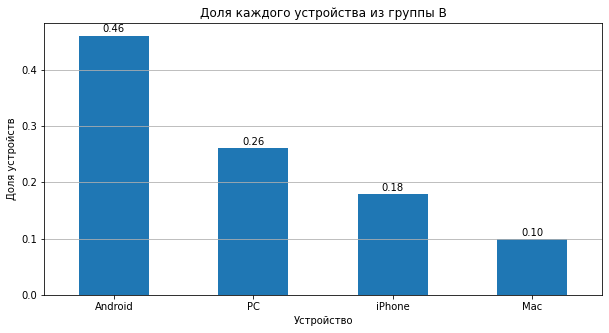

In [33]:
# Построим график столбчатой диаграммы
share_device_b.sort_values(ascending=False).plot(kind='bar',
               title='Доля каждого устройства из группы B',
               legend=False,
               ylabel='Доля устройств',
               xlabel='Устройство',
               rot=0,
               figsize=(10,5))
plt.grid(axis='y')

ax = plt.gca()
autolabel(ax.patches,  height_factor=1.01)

# Выводим график
plt.show()

**Итог по разделу:**
В результате анализа распределения пользователей каждого устройства по каждой группе установлено, что пользователи распределены по используемым устройствам схоже, разница процентов составляет до 2 %. В связи с чем, можно сделать вывод о сопоставимости пользователей в каждой группе.

<!-- ✅⚠️⛔❌🚩 -->
<div style="background-color: white; border: 2px solid black; border-radius: 20px; padding: 15px 25px; display: inline-block; color: black;">


##### ✅ Расчёт распределения пользователей 

- по устройствам 👆 
- и регионам 👇

---

⛔️ Сейчас доля завышена, так как считаются не только уникальные пользователи, что приведёт к некорректным выводам. Важно учитывать число уникальных пользователей для каждого устройства/региона — для этого корректнее использовать метод `nunique()`.

Важно учитывать число уникальных пользователей для каждого устройства а этом шаге и регионов в следующем.

Ориентиры:

|         |   A  |  B   |
|---------|------|------|    
| Android |	44.4 | 45.5 |
| Mac     | 10.5 | 10.1 |
| PC      | 24.9 | 25.9 |
| iPhone  | 20.0 | 18.3 |

|      |  A   |  B   |
|------|------|------|
| CIS  | 43.6 | 44.0 |
| EU   | 15.2 | 14.8 |
| MENA | 41.2 | 41.2 |


---

💬 Исправила. Правда посмотрела, что если смотреть в %, есть небольшое рассхождение с нашими данными в разбивке по устройствам, по некоторым 0,1%, подумала что такая ситуация произошла из-за округления. Вроде в остальном все должно быть правильно... по регионам совпадает полностью.
    Оставила все таки данные в долевом выражении, как по заданию
    
---
    
✅  Все правильно сделала.    

#### 3.4. Равномерность распределения пользователей по регионам<a id='2.3.4'></a>
Теперь убедитесь, что пользователи равномерно распределены по регионам.

Постройте две диаграммы:

- доля каждого региона для пользователей из группы A,

- доля каждого региона для пользователей из группы B.

Постарайтесь добавить на диаграммы все необходимые подписи, пояснения и заголовки, которые позволят сделать вывод о том, совпадает ли распределение регионов в группах A и B. Постарайтесь использовать другой тип диаграммы, не тот, что в прошлом задании.


In [34]:
# рассчитаем уникальных пользователей по регионам
total_region_a = sessions_test_part_df[sessions_test_part_df['test_group'] == 'A'].groupby('region')['user_id'].nunique()
share_region_a = round(total_region_a / total_region_a.sum() , 2)
share_region_a

region
CIS     0.44
EU      0.15
MENA    0.41
Name: user_id, dtype: float64

In [35]:
# рассчитаем уникальных пользователей по регионам
total_region_b = sessions_test_part_df[sessions_test_part_df['test_group'] == 'B'].groupby('region')['user_id'].nunique()
share_region_b = round(total_region_b / total_region_b.sum() , 2)
share_region_b

region
CIS     0.44
EU      0.15
MENA    0.41
Name: user_id, dtype: float64

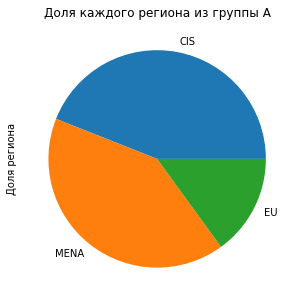

In [36]:
# Построим график столбчатой диаграммы
share_region_a.sort_values(ascending=False).plot(kind='pie',
               title='Доля каждого региона из группы А',
               legend=False,
               ylabel='Доля региона',
               xlabel='Устройство',
               rot=0,
               figsize=(10,5))
plt.grid(axis='y')

# Выводим график
plt.show()

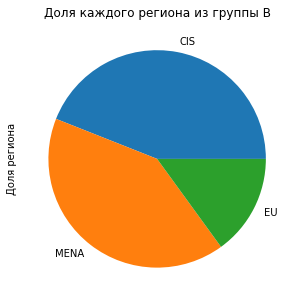

In [37]:
# Построим график столбчатой диаграммы
share_region_b.sort_values(ascending=False).plot(kind='pie',
               title='Доля каждого региона из группы B',
               legend=False,
               ylabel='Доля региона',
               xlabel='Устройство',
               rot=0,
               figsize=(10,5))
plt.grid(axis='y')

# Выводим график
plt.show()

**Итог по разделу:**
В результате анализа распределения пользователей каждого региона по каждой группе установлено, что пользователи распределены по региону схоже, разница процентов менее 1%. В связи с чем, можно сделать вывод о сопоставимости пользователей в каждой группе.

#### 3.5. Вывод после проверки A/B-теста<a id='2.3.5'></a>

На основе проведённого анализа A/B-теста сформулируйте и запишите свои выводы. В выводе обязательно укажите:

- Было ли обнаружено различие в количестве пользователей в двух группах.

- Являются ли выборки независимыми. Было ли обнаружено пересечение пользователей из тестовой и контрольной групп.

- Сохраняется ли равномерное распределение пользователей тестовой и контрольной групп по категориальным переменным: устройствам и регионам.

Сделайте заключение: корректно ли проходит A/B-тест, или наблюдаются какие-либо нарушения.

**Вывод после проверки А/В-теста:**
- Существенного различия в количестве пользователей по каждой группе не выявлено.
- Выборки по каждой группе независимые, пересечение пользователей не выявлено.
- По категориальным переменным не выявлено существенных различий. По устройствам группы распределены равномерно с разницей процентов в один пункт, по регионам имеется бОльшее различие в 10 пунктов.

В целом возможно сделать вывод о корректности прохождения А/В-теста.

<!-- ✅⚠️⛔❌🚩 -->
<div style="background-color: white; border: 2px solid black; border-radius: 20px; padding: 15px 25px; display: inline-block; color: black;">

##### ✅  Вывод после проверки A/B-теста

---

⚠️ В A/B-тестировании важно, чтобы распределение пользователей по группам было максимально равномерным — особенно при оценке долей (например, конверсий).
    
Отклонение в 5% и более между размерами групп считается критичным, так как оно может:
- исказить метрики (например, если одна группа в 1.5 раза больше другой — её вклад в суммарные значения будет непропорционален);
- снизить статистическую мощность теста;
- повлиять на интерпретацию результатов (особенно если наблюдается эффект, обусловленный размером группы, а не самим изменением в продукте).
    
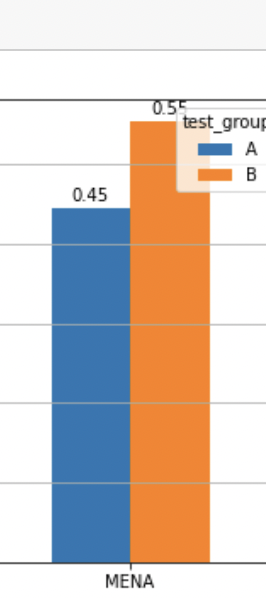
    
Однако в данном случае дисбаланс, показанный на графике, вызван ошибкой в расчётах.
После их исправления распределение между группами окажется корректным — и первоначальный вывод (что дисбаланс критичен) перестаёт быть актуальным.
    
---    

💬 Все исправила. Как добавить оба показателя одновременно на один столбчатый график не сообразила. Тем не менее, по заданию нужно 2 отдельных графика, поэтому оставила пайчарты

---
    
✅ Договорились.    

### 4. Проверка результатов A/B-теста<a id='2.4'></a>

A/B-тест завершён, и у вас есть результаты за все дни проведения эксперимента. Необходимо убедиться в корректности теста и верно интерпретировать результаты.

#### 4.1. Получение результатов теста и подсчёт основной метрики<a id='2.4.1'></a>

- Считайте и сохраните в датафрейм `sessions_test` CSV-файл с историческими данными о сессиях пользователей `sessions_project_test.csv`.

- В датафрейме `sessions_test` создайте дополнительный столбец `good_session`. В него войдёт значение `1`, если за одну сессию было просмотрено 4 и более страниц, и значение `0`, если просмотрено меньше.

In [38]:
# Выгружаем данные в переменные 
sessions_test_df = pd.read_csv('https://code.s3.yandex.net/datasets/sessions_project_test.csv')

In [39]:
# Выгружаем первые 5 строк датафрейма
sessions_test_df.head()

,user_id,session_id,session_date,session_start_ts,install_date,session_number,registration_flag,page_counter,region,device,test_group
0,6DAE3B3654DA738E,C69249E26E58F6E2,2025-10-26,2025-10-26 18:15:05,2025-10-16,3,0,3,MENA,Android,A
1,0A3FE5D1DD59110A,66D66D7C9F5181B7,2025-10-21,2025-10-21 17:04:53,2025-10-15,2,1,2,CIS,Android,B
2,2041F1D7AA740B88,50DE51D42215E74C,2025-10-23,2025-10-23 17:39:29,2025-10-19,3,0,2,MENA,Android,A
3,43D7585009168086,5763C0C353C22263,2025-10-24,2025-10-24 15:01:57,2025-10-18,4,0,1,CIS,iPhone,B
4,15AD68B14D62D88C,B1AD09F93C1053BC,2025-10-17,2025-10-17 17:34:39,2025-10-17,1,0,2,MENA,Android,B


In [40]:
# Меняем тип данных на datetime64 в датафрейме
for column in ['session_date', 'session_start_ts', 'install_date']:
    sessions_test_df[column] = pd.to_datetime(sessions_test_df[column])

In [41]:
# Создадим новый столбец 'good_session' для анализа результатов 
sessions_test_df['good_session'] = 0
sessions_test_df.loc[sessions_test_df['page_counter'] >= 4, 'good_session'] = 1
sessions_test_df.head()

,user_id,session_id,session_date,session_start_ts,install_date,session_number,registration_flag,page_counter,region,device,test_group,good_session
0,6DAE3B3654DA738E,C69249E26E58F6E2,2025-10-26,2025-10-26 18:15:05,2025-10-16,3,0,3,MENA,Android,A,0
1,0A3FE5D1DD59110A,66D66D7C9F5181B7,2025-10-21,2025-10-21 17:04:53,2025-10-15,2,1,2,CIS,Android,B,0
2,2041F1D7AA740B88,50DE51D42215E74C,2025-10-23,2025-10-23 17:39:29,2025-10-19,3,0,2,MENA,Android,A,0
3,43D7585009168086,5763C0C353C22263,2025-10-24,2025-10-24 15:01:57,2025-10-18,4,0,1,CIS,iPhone,B,0
4,15AD68B14D62D88C,B1AD09F93C1053BC,2025-10-17,2025-10-17 17:34:39,2025-10-17,1,0,2,MENA,Android,B,0


#### 4.2. Проверка корректности результатов теста<a id='2.4.2'></a>

Прежде чем приступать к анализу ключевых продуктовых метрик, необходимо убедиться, что тест проведён корректно и вы будете сравнивать две сопоставимые группы.

- Рассчитайте количество уникальных сессий для каждого дня и обеих тестовых групп, используя группировку.

- Проверьте, что количество уникальных дневных сессий в двух выборках не различается или различия не статистически значимыми. Используйте статистический тест, который позволит сделать вывод о равенстве средних двух выборок.

- В качестве ответа выведите на экран полученное значение p-value и интерпретируйте его.

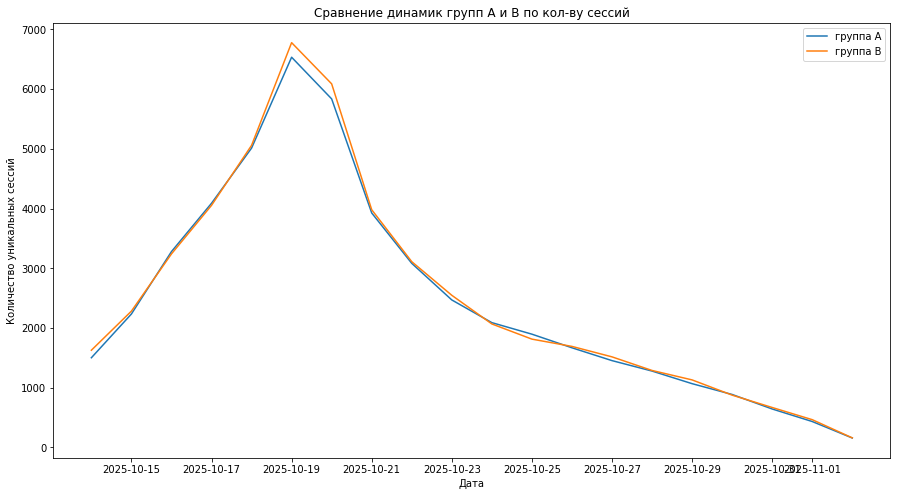

In [42]:
session_gr = sessions_test_df.groupby(['test_group', 'session_date'])['session_id'].nunique().reset_index()

x = session_gr.session_date.unique()
y_a = session_gr[session_gr.test_group=='A'].session_id
y_b = session_gr[session_gr.test_group=='B'].session_id

plt.figure(figsize=(15, 8))
plt.plot(x, y_a, label ='группа A')
plt.plot(x, y_b,label ='группа B')

plt.xlabel("Дата")
plt.ylabel("Количество уникальных сессий")
plt.legend()
plt.title('Сравнение динамик групп A и B по кол-ву сессий')

plt.show()

<!-- ✅⚠️⛔❌🚩 -->
<div style="background-color: white; border: 2px solid black; border-radius: 20px; padding: 15px 25px; display: inline-block; color: black;">

##### ✅  Визуализация

---

⛔ Подписи осей слились.
    
![image.png](attachment:image.png)    

---    

💬 Поправила тип данных, стало лучше, правда, все равно немного слились..., пробовала добавить вот такой код
    
```py 
import matplotlib.dates as mdates
months = mdates.MonthLocator()
days = mdates.DayLocator()
timeFmt = mdates.DateFormatter('%Y-%m')
fig, ax = plt.subplots()
ax.xaxis.set_major_locator(months)
ax.xaxis.set_major_formatter(timeFmt)
ax.xaxis.set_minor_locator(days)
```

    но почему-то все равно не работает
---
    
✅ Сейчас все работает и отображается корректно.
    
![image-2.png](attachment:image-2.png)    

**Формулировка гипотезы:**

Ключевая метрика: Количество уникальных дневных сессий

Нулевая гипотеза: Количество уникальных дневных сессий не различается μ(А) = μ(В)

Альтернативная гипотеза: Количество уникальных дневных сессий в тестовой группе В и в контрольной группе не равны А μ(B) ≠ μ(A)

In [43]:
metric_a = session_gr[session_gr.test_group=='A']['session_id'] ## выборка целевой метрики для группы A
metric_b = session_gr[session_gr.test_group=='B']['session_id'] ## выборка целевой метрики для группы B

alpha = 0.05 ## на каком уровне значимости проверяем гипотезу о равенстве выборочных средних

stat_welch_ttest, p_value_welch_ttest = ttest_ind(
    metric_a, 
    metric_b, 
    equal_var=False,
    alternative='two-sided' ## поскольку альтернативная гипотеза о том, что выборочное среднее первой выборки и второй выборки неравны
) ## применяем t-тест Уэлча
if p_value_welch_ttest>alpha:
    print(f'p-value теста Уэлча ={round(p_value_welch_ttest, 2)}')
    print('Нулевая гипотеза находит подтверждение! Выборочные средние в группах A и B равны')
    print('Интерпретация: Создание нового алгоритма рекомендательных систем не изменило количества сессий')
else:
    print(f'p-value теста Уэлча ={round(p_value_welch_ttest, 2)}')
    print('Нулевая гипотеза не находит подтверждения! Выборочные средние в группах A и B не равны')
    print('Интерпретация: создание нового алгоритма рекомендательных систем изменило количество сессий в группе В')

p-value теста Уэлча =0.94
Нулевая гипотеза находит подтверждение! Выборочные средние в группах A и B равны
Интерпретация: Создание нового алгоритма рекомендательных систем не изменило количества сессий


<!-- ✅⚠️⛔❌🚩 -->
<div style="background-color: white; border: 2px solid black; border-radius: 20px; padding: 15px 25px; display: inline-block; color: black;">

##### ✅ Формулировка гипотез перед статистическим тестом

---

⚠️ Ты проверяешь то, чего нет. 😉. Сформулированные гипотезы - это часть теста.

Перед проверкой теста важно всегда формулировать нулевую (H₀) и альтернативную (H₁) гипотезы, чтобы было понятно, какие различия мы проверяем.

В нулевой гипотезе обычно утверждают отсутствие эффекта или различий (например, "равны" или "не отличаются"), а альтернативная гипотеза (H₁) предполагают наличие эффекта или различия (например, "отличаются", "больше" или "меньше").
    
Если направление не задано, то:   
* H₀ - равны;   
* H₁ - отличаются.   

**Значит**:

- H₀ (нулевая гипотеза) — количество уникальных дневных сессий `не различается` между тестовой и контрольной группами.
- H₁ (альтернативная гипотеза) — количество уникальных дневных сессий `различается` между тестовой и контрольной группами.

    
Значения nan, 0 и 1 первый признак некорректного расчета, это может указывать на проблемы в расчётах или наличие идентичных или вырожденных данных.    
    
Подробнее можно почитать [здесь](https://allatambov.github.io/psms/pdf/hypo-test.pdf)    


---

💬 Не понимаю. Гипотеза же была сформулирована в 2.2.1?
    
---
    
⚠️ Ты путаешь. Смотрт, для каждого теста нужно писать своб гипотезу. Здесь вообще двусторонняя гипотеза, а для основного односторонняя. Это разные тесты и в них проверяются разные вещи.
    


---

💬 Поняла, откорректировала здесь, изменила на двустороннюю, изменила итоги
    
---
    
✅ Отлично!    

**Итог по разделу:**
- В результате анализа динамики количества пользователей по каждой группе выявлено, что количество пользователей по каждой группе за весь период эксперимента распределены равномерно.
- В результате проведения А/В-теста установлено, что нулевая гипотеза находит подтверждения. Выборочные средние (количество сессий) в группах A и B равны. Т.е. создание нового алгоритма рекомендательных систем не привело к увеличению количества сессий.

#### 4.3. Сравнение доли успешных сессий<a id='2.4.3'></a>

Когда вы убедились, что количество сессий в обеих выборках не различалось, можно переходить к анализу ключевой метрики — доли успешных сессий.

Используйте созданный на первом шаге задания столбец `good_session` и рассчитайте долю успешных сессий для выборок A и B, а также разницу в этом показателе. Полученный вывод отобразите на экране.

In [44]:
# Определим долю успешных сессий по каждой тестовой группе
p_session = sessions_test_df.groupby('test_group')['good_session'].mean()
p_session

test_group
A    0.307723
B    0.318290
Name: good_session, dtype: float64

In [45]:
# Рассчитаем процентную разницу доли успешных сессий 
p_session_dif = 100 * abs(p_session['A'] - p_session['B']) / p_session['A']

print(f'Разница в доле успешных сессий в группах A и B составляет: {p_session_dif.round(2)}%, т.е. чуть более {floor(p_session_dif)}%.')

Разница в доле успешных сессий в группах A и B составляет: 3.43%, т.е. чуть более 3%.


**Итог по разделу:**
Разница в доле успешных сессий в группах А и В составляет 3,43%, что выше заданного уровня MDE.

<div style="background-color: white; border: 2px solid black; border-radius: 20px; padding: 15px 25px; display: inline-block; color: black;">

##### ✅ Расчёт доли успешных сессий

---

✅ Все правильно. Сравнение доли успешных сессий — важный шаг, потому что именно эта метрика показывает, насколько эффективно пользователи достигают целевого действия при взаимодействии с продуктом.
 
Если доля успешных сессий в одной из групп выше, это может говорить о том, что изменения, протестированные в этой группе, положительно повлияли на пользовательский опыт. А значит, они могут быть внедрены в основную версию продукта.

Без такой проверки невозможно оценить реальное влияние нововведения — даже если распределение сессий по группам было корректным.

---

💬 спасибо 👍

#### 4.4. Насколько статистически значимо изменение ключевой метрики<a id='2.4.4'></a>

На предыдущем шаге вы убедились, что количество успешных сессий в тестовой выборке примерно на 1.1% выше, чем в контрольной, но делать выводы только на основе этого значения будет некорректно. Для принятия решения всегда необходимо отвечать на вопрос: является ли это изменение статистически значимым.

- Используя статистический тест, рассчитайте, является ли изменение в метрике доли успешных сессий статистически значимым.

- Выведите на экран полученное значение p-value и свои выводы о статистической значимости. Напомним, что уровень значимости в эксперименте был выбран на уровне 0.05.

In [46]:
n_a, n_b = sessions_test_df[sessions_test_df.test_group=='A'].shape[0], sessions_test_df[sessions_test_df.test_group=='B'].shape[0] ## размеры выборок A и B
m_a = sessions_test_df[(sessions_test_df.test_group=='A')&(sessions_test_df.good_session==1)].shape[0] # количество успехов в группе A
m_b = sessions_test_df[(sessions_test_df.test_group=='B')&(sessions_test_df.good_session==1)].shape[0] # количество успехов в группе B
alpha = 0.05

p_a, p_b = m_a/n_a, m_b/n_b # рассчитываем доли успехов для каждой группы: A и B

print(f'n_a={n_a}, n_b={n_b}')

print(f'm_a={m_a}, m_b={m_b}')

print(f'p_a={p_a}, p_b={p_b}')

if (p_a*n_a > 10)and((1-p_a)*n_a > 10)and(p_b*n_b > 10)and((1-p_b)*n_b > 10):
    print('Предпосылка о достаточном количестве данных выполняется!')
else:
    print('Предпосылка о достаточном количестве данных НЕ выполняется!')
    
stat_ztest, p_value_ztest = proportions_ztest(
    [m_a, m_b],
    [n_a, n_b],
    alternative='smaller' 
)

if p_value_ztest > alpha:
    print(f'pvalue={p_value_ztest} > {alpha}')
    print('Нулевая гипотеза находит подтверждение!')
else:
    print(f'pvalue={p_value_ztest} < {alpha}')
    print('Нулевая гипотеза не находит подтверждения!')

n_a=49551, n_b=50454
m_a=15248, m_b=16059
p_a=0.3077233557344958, p_b=0.31828992745867524
Предпосылка о достаточном количестве данных выполняется!
pvalue=0.0001574739988036123 < 0.05
Нулевая гипотеза не находит подтверждения!


<!-- ✅⚠️⛔❌🚩 -->
<div style="background-color: white; border: 2px solid black; border-radius: 20px; padding: 15px 25px; display: inline-block; color: black;">

##### ✅ Z-test

----
    
⛔️ В строке sessions_test_df[sessions_test_df=='B'] есть ошибка — вместо test_group=='B' ты сравниваешь весь датафрейм с ‘B’. Это даст неверные размеры выборки для группы B.
    
Ориентир: 50454    


---

💬 исправила
    
---
    
✅ Молодец, все правильно.

**Итог по разделу:**
В результате проведенного Z-теста пропорций установлено, что предпосылка о достаточном количестве данных выполняется,изменение показателя является статистически значимым.
Нулевая гипотеза не находит подтверждения. 

#### 4.5. Вывод по результатам A/B-эксперимента<a id='2.4.5'></a>

На основе проведённого анализа результатов теста сформулируйте и запишите свои выводы для команды разработки приложения. В выводе обязательно укажите:

- Характеристики проведённого эксперимента, количество задействованных пользователей и длительность эксперимента.

- Повлияло ли внедрение нового алгоритма рекомендаций на рост ключевой метрики и как.

- Каким получилось значение p-value для оценки статистической значимости выявленного эффекта.

- Стоит ли внедрять нововведение в приложение.

**Общий вывод по результатам проведенного А/В-эксперимента**

- В результате проведенного мониторинга А/В-теста за первый день проведения эксперимента, установлено, что количество пользователей в каждой группе распределено равномерно. Для проведения эксперимента необходимо 41040 пользователей в каждой группе и 9 дней. В целом распределение по категориальным переменным равномерное.
- В соответствии с проведенным статистическим тестом Уэлча установлено, что выборочные средние в группах A и B равны, создание нового алгоритма рекомендательных систем не привело к увеличению количества сессий. Pvalue теста составил 0.47, что меньше заданного уровня значимости.
- В результате проведения Z-теста пропорций доли успешных сессий показал, что изменение показателя является статистически значимым, нулевая гипотеза не находит подтверждения. Т.е. внедрение нового алгоритма рекомендаций увеличило показатель успешных сессий.

**Таким образом, на основании проведенных статистических тестов было установлено, что внедрение нового алгоритма рекомендаций повлияло на рост ключевой метрики. Рекомендуется внедрение нововведения в приложении.**

<div style="background-color: white; border: 2px solid black; border-radius: 20px; padding: 15px 25px; display: inline-block; color: black;">

##### ✅ Итоговый аналитический вывод

---
     
⛔️ Как так? =)
    
В гипотезах и тесте:    
    
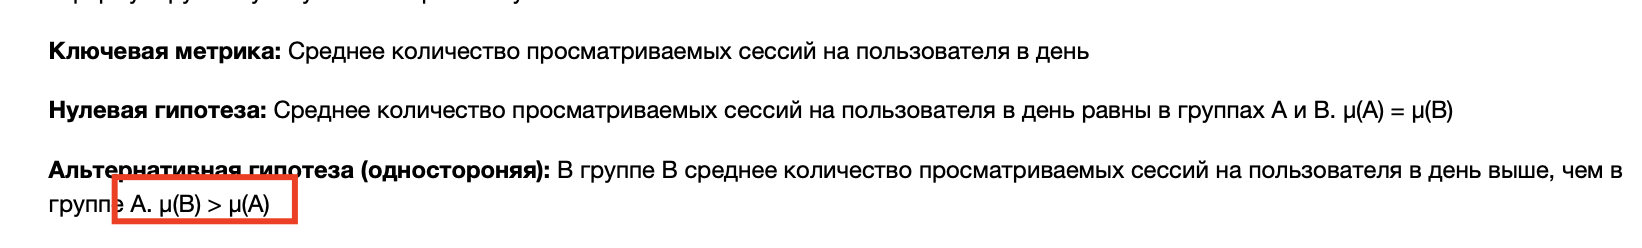    
    
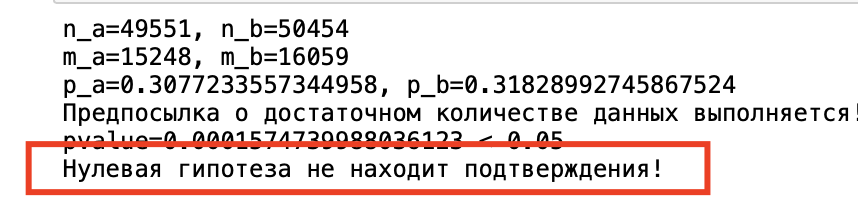    
    
А в выводе:
    
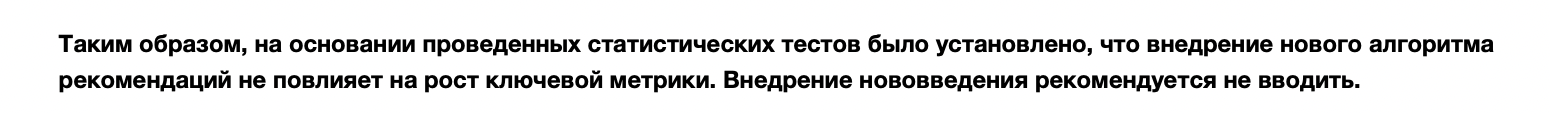    

---

💬 Все исправила!
    
✅ Все правильно.    

<!-- ✅⚠️⛔❌🚩 -->
<div style="background-color: white; border: 2px solid black; border-radius: 20px; padding: 15px 25px; display: inline-block; color: black;">
    
## 🏁 **Итоги ревью**
<a id="results"></a>
[В начало](#start)

---

⛔️ Мария, спасибо за работу. Осталось исправить несколько комментариев и можно идти к заказчику. Молодец! 👍
    
Для удобства, комментарии которые нужно скорректировать я добавил в меню **Contents** слева.
    
Жду новую версию проекта. 🙂

---

💬 Спасибо за обратную связь! исправила критичные и некритичные замечания, жду ответ на новую версию проекта 🙂 Буду рада услышать рекомендации на что обратить особое внимание в дальнейшей работе с данными.
    
---

⛔️ Почти все отлично. Про формулировку в 4.2 ответил, а вывод, похоже просто забыла переписать. Вернул так как ради итогового вывода делали исследования, а ответ не тот.
    
---

💬 Да, все верно, согласна. Все исправила.
    
---

<div style="background-color: black; border: 2px solid #444; border-radius: 20px; padding: 15px 25px; display: inline-block; color: white;">

## ✌️ **Мария, поздравляю - проект принят!** 🥳 🎉 
    

Ты умница!    
 

💪 Еще раз спасибо за хорошую работу, твои комментарии и внесенные корректировки! Критических замечаний нет. Если у тебя есть вопросы, их можно задать через куратора.
    
**Успехов в дальнейшем обучении и карьере! 🚀**

**Артем 🤝**    

<img src="https://lifeo.ru/wp-content/uploads/gif-salyut-10.gif"> 
    
---
    
## 📖 **Полезные ссылки**

* [Работа в Яндексе](https://yandex.ru/jobs/pages/analytics_interview?ysclid=l84s63fs1g790141490)
* [Настройте свой Jupyter Notebook правильно](https://medium.com/nuances-of-programming/настройте-свой-jupyter-notebook-правильно-faef14c89434)    
* [PEP 8 – Style Guide for Python Code](https://www.python.org/dev/peps/pep-0008/)    
* [Обработка пропусков в данных](https://loginom.ru/blog/missing)  
* [Разделение данных с помощью qcut и cut в Pandas](https://dfedorov.spb.ru/pandas/Разделение%20данных%20в%20Pandas%20с%20помощью%20qcut%20и%20cut.html?)  
* [Официальная документаци метода qcut](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.qcut.html)  
* [Подробное руководство по группировке и агрегированию с помощью pandas](https://dfedorov.spb.ru/pandas/Подробное%20руководство%20по%20группировке%20и%20агрегированию%20с%20помощью%20pandas.html?ysclid=lcmm6rtg2w602526506)
* [Проверка статистических гипотез. (21 мая 2020 г.)](https://allatambov.github.io/psms/pdf/hypo-test.pdf)    
* [Шпаргалка по визуализации данных в Python с помощью Plotly](https://habr.com/ru/articles/502958/) 
* [Тест гигиены визуализации данных](https://bar-or-pie.dianov.org)    
* [Задачки SQL](https://habr.com/ru/company/dcmiran/blog/500360/)    
* [7 cайтов для оттачивания навыка написания SQL запросов на 2020 год](https://techrocks.ru/2019/11/22/7-sites-to-perfect-sql-query-writing-skills/)
* [Главред помогает очистить текст от словесного мусора, проверяет на соответствие информационному стилю.](https://glvrd.ru)

</div>